读取后的数据 (HSTECH.txt) 前5行:
           日期       开盘       最高       最低       收盘     成交量       成交额
0 2022-01-03  5704.38  5741.80  5609.79  5640.47  1173.0  11729.08
1 2022-01-04  5665.89  5678.69  5550.56  5581.90  1992.0  19919.92
2 2022-01-05  5501.75  5505.46  5306.25  5323.47  4301.0  43006.84
3 2022-01-06  5285.43  5410.44  5230.94  5396.65  3510.0  35103.01
4 2022-01-07  5470.06  5517.49  5399.22  5503.91  3372.0  33719.64
HSTECH.txt 缺失值情况:
 日期     0
开盘     0
最高     0
最低     0
收盘     0
成交量    0
成交额    0
dtype: int64
HSTECH.txt 异常值处理后的数据前5行:
           日期           开盘           最高           最低       收盘     成交量       成交额
0 2022-01-03  5660.341983  5717.380299  5570.348343  5640.47  1173.0  11729.08
1 2022-01-04  5660.341983  5678.690000  5550.560000  5581.90  1992.0  19919.92
2 2022-01-05  5501.750000  5505.460000  5306.250000  5323.47  4301.0  43006.84
3 2022-01-06  5285.430000  5410.440000  5230.940000  5396.65  3510.0  35103.01
4 2022-01-07  5470.060000  5517.490000  5399.220000  550

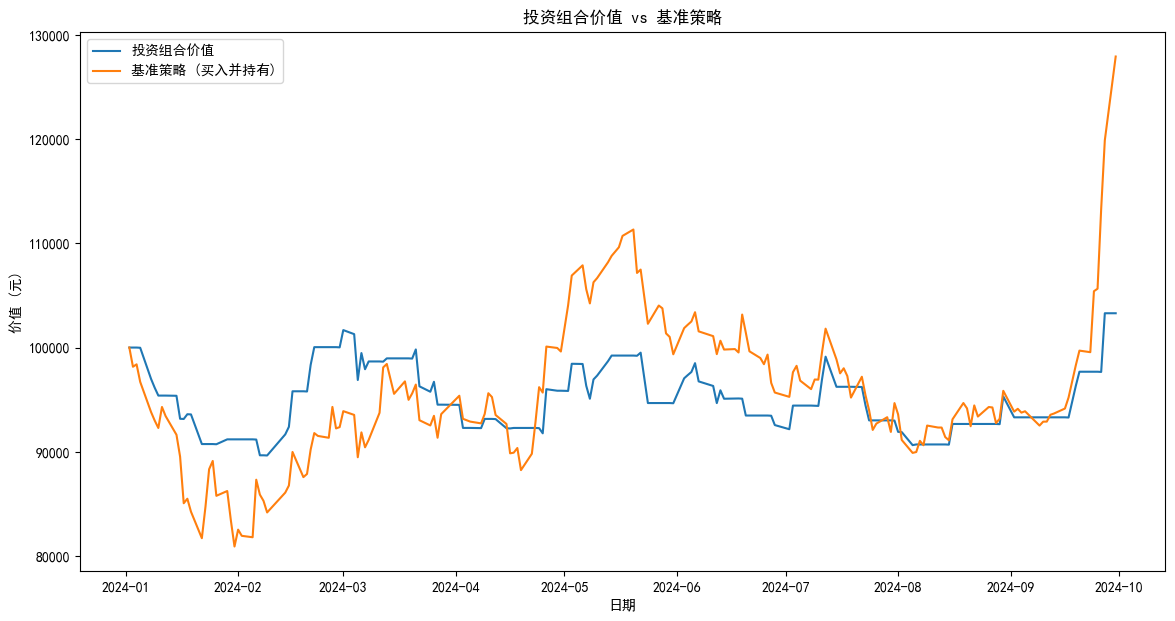

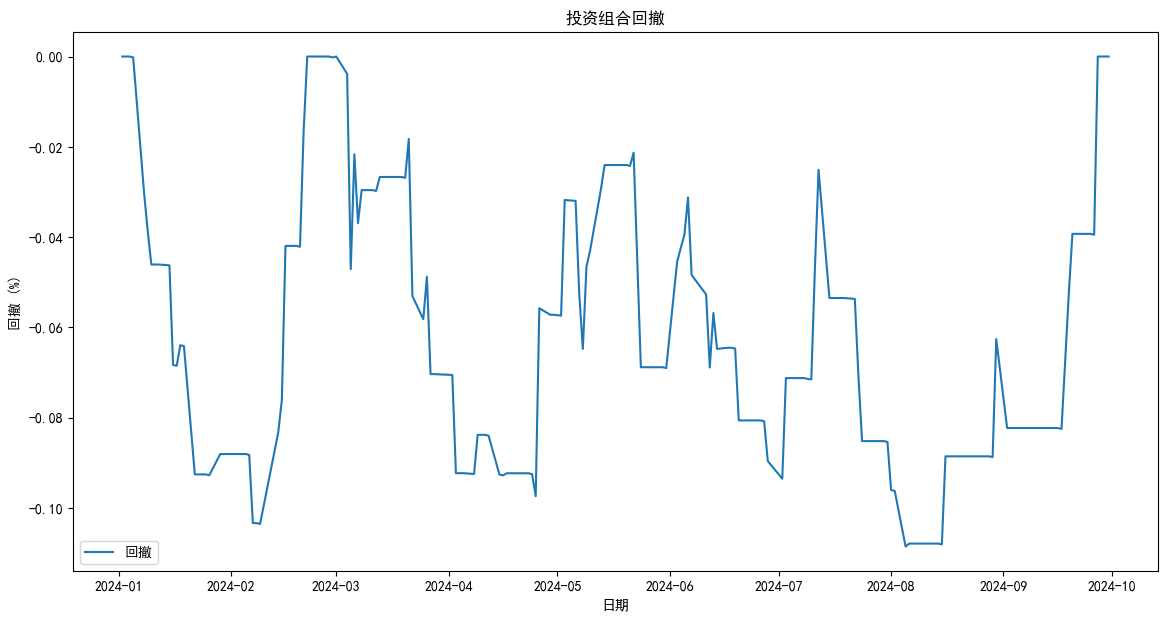

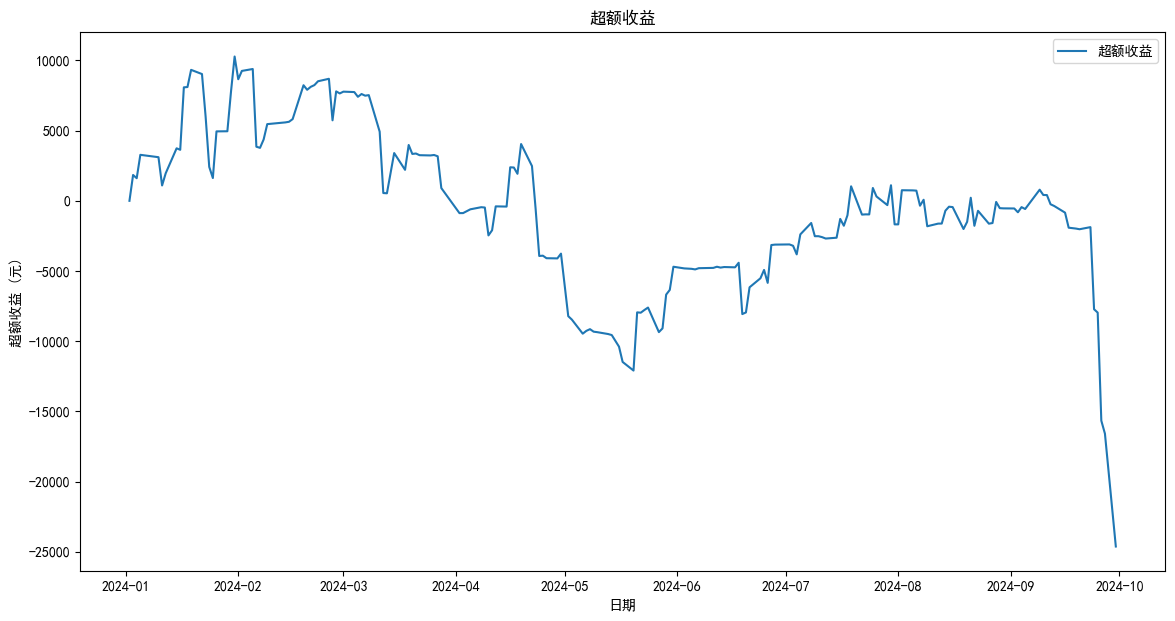

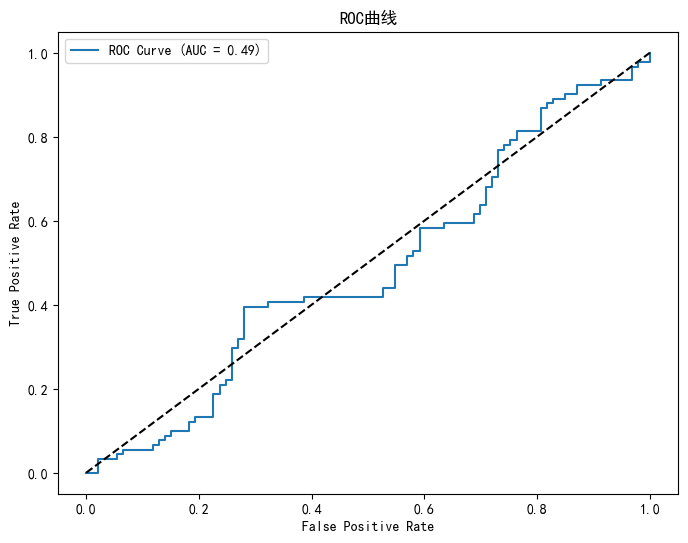

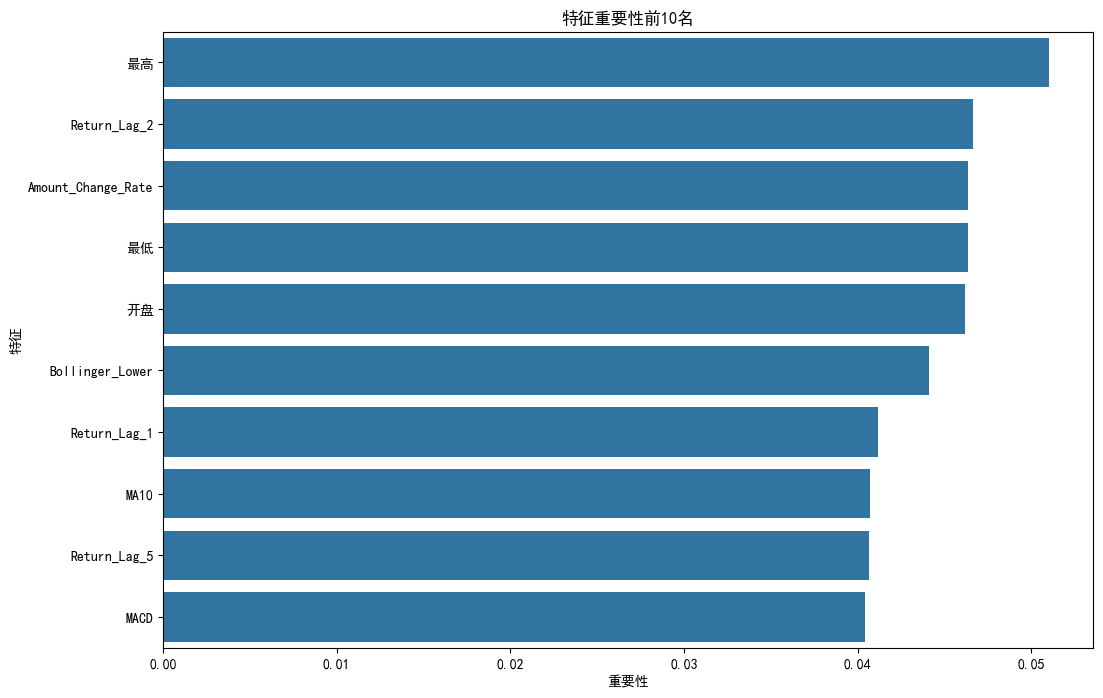

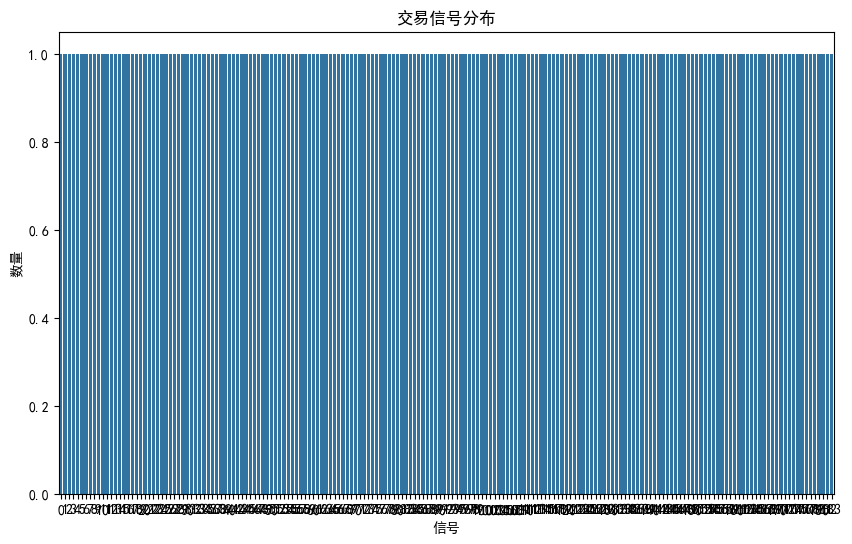


分类报告:
              precision    recall  f1-score   support

           0       0.53      0.72      0.61        93
           1       0.54      0.34      0.42        91

    accuracy                           0.53       184
   macro avg       0.54      0.53      0.51       184
weighted avg       0.54      0.53      0.52       184



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import warnings
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import os

class MLStrategy:
    '''
    机器学习指数增强策略
    '''
    def __init__(self, train_years=2, year_days=240, initial_capital=100000, slippage=0.0002,
                 investment_start='2024-01-01', investment_end='2024-09-30'):
        """
        初始化机器学习策略参数。
        Args:
            train_years (int): 训练样本的年数。
            year_days (int): 一年有多少个交易日。
            initial_capital (float): 初始资金。
            slippage (float): 滑点。
            investment_start (str): 投资开始日期。
            investment_end (str): 投资结束日期。
        """
        self.train_years = train_years  # 训练样本的年数
        self.year_days = year_days      # 一年有多少个交易日
        self.initial_capital = initial_capital  # 初始资金
        self.slippage = slippage        # 滑点
        self.scaler = StandardScaler()
        self.investment_start = pd.to_datetime(investment_start)
        self.investment_end = pd.to_datetime(investment_end)
        self.feature_names = None       # 存储特征名称
        self.model = None               # 存储训练好的模型

    def read_and_clean_data(self, file_path, is_minute=False):
        '''
        读取并清洗数据文件，处理编码和无效行，并进行异常值处理。
        Returns:
            DataFrame: 清洗后的数据框。
        '''
        if not os.path.exists(file_path):
            print(f"文件 {file_path} 不存在。")
            return None

        try:
            data = pd.read_csv(file_path, encoding='gbk', delimiter='\t', skiprows=1, on_bad_lines='skip')
        except Exception as e:
            print(f"读取文件 {file_path} 时出错: {e}")
            return None
        data.columns = data.columns.str.strip().str.replace('\u3000', '').str.replace(' ', '')
        if '日期' not in data.columns:
            print(f"文件 {file_path} 中缺少 '日期' 列。列名为: {data.columns.tolist()}")
            return None

        # 转换 '日期' 列为 datetime，非日期值转换为 NaT
        data['日期'] = pd.to_datetime(data['日期'], format='%Y-%m-%d', errors='coerce')

        # 删除 '日期' 为 NaT 的行
        data = data.dropna(subset=['日期']).reset_index(drop=True)

        # 如果是5分钟线数据，处理时间格式
        if is_minute:
            data = self.process_minute_time(data)

        # 检查数据
        print(f"读取后的数据 ({file_path}) 前5行:\n", data.head())
        print(f"{file_path} 缺失值情况:\n", data.isnull().sum())

        # 填补缺失值（前向填充和后向填充）
        data.fillna(method='ffill', inplace=True)
        data.fillna(method='bfill', inplace=True)

        # 异常值处理：使用中位数法去极值
        numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
        for col in numeric_cols:
            median = data[col].median()
            std = data[col].std()
            # 定义阈值，这里以3倍标准差为例
            upper = median + 3 * std
            lower = median - 3 * std
            data[col] = np.where(data[col] > upper, upper, data[col])
            data[col] = np.where(data[col] < lower, lower, data[col])

        print(f"{file_path} 异常值处理后的数据前5行:\n", data.head())

        return data

    def process_minute_time(self, df):
        '''
        处理5分钟线数据的时间格式，并创建Datetime列。
        Returns:
            DataFrame: 处理后的数据框。
        '''
        def convert_time(x):
            x = str(int(x)).zfill(4)  # 确保是4位数
            return f"{x[:2]}:{x[2:]}"

        if '时间' not in df.columns:
            print("5分钟线数据中缺少 '时间' 列。")
            return df

        df['时间'] = df['时间'].apply(convert_time)
        df['Datetime'] = pd.to_datetime(df['日期'].dt.strftime('%Y-%m-%d') + ' ' + df['时间'], errors='coerce')

        # 删除 'Datetime' 为 NaT 的行
        df = df.dropna(subset=['Datetime']).reset_index(drop=True)
        print("处理后的5分钟线数据前5行:\n", df.head())
        return df

    def feature_engineering(self, daily_data, minute_data):
        '''
        构建特征工程，包括技术指标和5分钟线特征。
        Returns:
            DataFrame: 包含特征的DataFrame。
        '''
        data = daily_data.copy()

        # 计算收益率
        data['Return'] = data['收盘'].pct_change()

        # 移动平均线
        data['MA5'] = data['收盘'].rolling(window=5).mean()
        data['MA10'] = data['收盘'].rolling(window=10).mean()
        data['MA20'] = data['收盘'].rolling(window=20).mean()

        # 相对强弱指数（RSI）
        def compute_rsi(series, window=14):
            delta = series.diff()
            gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
            rs = gain / loss
            rsi = 100 - (100 / (1 + rs))
            return rsi
        data['RSI'] = compute_rsi(data['收盘'], window=14)

        # MACD
        ema_short = data['收盘'].ewm(span=12, adjust=False).mean()
        ema_long = data['收盘'].ewm(span=26, adjust=False).mean()
        data['MACD'] = ema_short - ema_long
        data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

        # 布林带
        rolling_mean = data['收盘'].rolling(window=20).mean()
        rolling_std = data['收盘'].rolling(window=20).std()
        data['Bollinger_Upper'] = rolling_mean + (rolling_std * 2)
        data['Bollinger_Lower'] = rolling_mean - (rolling_std * 2)

        # ATR（平均真实波幅）
        high_low = data['最高'] - data['最低']
        high_prev_close = np.abs(data['最高'] - data['收盘'].shift(1))
        low_prev_close = np.abs(data['最低'] - data['收盘'].shift(1))
        tr = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
        data['ATR'] = tr.rolling(window=14).mean()

        # CCI（商品通道指数）
        typical_price = (data['最高'] + data['最低'] + data['收盘']) / 3
        data['CCI'] = (typical_price - typical_price.rolling(window=20).mean()) / (0.015 * typical_price.rolling(window=20).std())

        # 成交量变化率
        data['Volume_Change_Rate'] = data['成交量'].pct_change()

        # 成交额变化率
        data['Amount_Change_Rate'] = data['成交额'].pct_change()

        # 从5分钟线数据中提取特征
        minute_features = minute_data.groupby('日期').agg({
            '收盘': ['mean', 'std'],
            '成交量': 'sum',
            '成交额': 'sum'
        })
        minute_features.columns = ['Close_Mean_5min', 'Close_STD_5min', 'Volume_Sum_5min', 'Amount_Sum_5min']
        minute_features.reset_index(inplace=True)

        # 合并5分钟线特征到日线数据
        data = pd.merge(data, minute_features, on='日期', how='left')

        # 填补合并后的缺失值
        data.fillna(method='bfill', inplace=True)
        data.fillna(method='ffill', inplace=True)

        # 添加滞后特征
        for lag in range(1, 6):
            data[f'Return_Lag_{lag}'] = data['Return'].shift(lag)

        # 删除NaN值
        data.dropna(inplace=True)

        print("特征工程后的数据前5行:\n", data.head())

        return data

    def define_target(self, data):
        '''
        定义目标变量，预测下一天的收益率是否为正。

        Args:
            data (DataFrame): 含特征的数据框。

        Returns:
            DataFrame: 含目标变量的数据框。
        '''
        data['Target'] = np.where(data['Return'].shift(-1) > 0, 1, 0)
        data.dropna(inplace=True)
        print("定义目标变量后的数据前5行:\n", data.head())
        return data

    def prepare_features_labels(self, data):
        '''
        准备特征和标签，进行标准化。

        Args:
            data (DataFrame): 含特征和目标变量的数据框。

        Returns:
            X_scaled (DataFrame): 标准化后的特征。
            y (Series): 标签。
        '''
        features = [
            '开盘', '最高', '最低', '成交量', '成交额',
            'MA5', 'MA10', 'MA20', 'RSI', 'MACD', 'MACD_Signal',
            'Bollinger_Upper', 'Bollinger_Lower', 'ATR', 'CCI',
            'Volume_Change_Rate', 'Amount_Change_Rate',
            'Close_Mean_5min', 'Close_STD_5min', 'Volume_Sum_5min', 'Amount_Sum_5min',
            'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Return_Lag_4', 'Return_Lag_5'
        ]
        # 检查特征列是否存在
        missing_features = [feat for feat in features if feat not in data.columns]
        if missing_features:
            print(f"警告: 以下特征列缺失: {missing_features}")

        # 仅选择存在的特征列
        available_features = [feat for feat in features if feat in data.columns]
        X = data[available_features]
        y = data['Target']

        # 标准化特征
        X_scaled = self.scaler.fit_transform(X)
        X_scaled = pd.DataFrame(X_scaled, columns=available_features, index=data.index)

        print("准备特征和标签后的特征前5行:\n", X_scaled.head())

        return X_scaled, y

    def split_data(self, X, y, data):
        '''
        数据划分，训练集和测试集，并对训练集应用SMOTE。
        Returns:
            X_train_res, X_test, y_train_res, y_test (DataFrames/Series): 划分并过采样后的数据。
        '''
        # 训练集：投资开始日期前的train_years年
        train_end_date = self.investment_start - pd.Timedelta(days=1)
        train_start_date = train_end_date - pd.DateOffset(years=self.train_years)

        # 测试集：投资开始日期到投资结束日期
        test_start_date = self.investment_start
        test_end_date = self.investment_end

        # 获取训练集索引
        train_mask = (data['日期'] >= train_start_date) & (data['日期'] <= train_end_date)
        X_train = X[train_mask]
        y_train = y[train_mask]

        # 获取测试集索引
        test_mask = (data['日期'] >= test_start_date) & (data['日期'] <= test_end_date)
        X_test = X[test_mask]
        y_test = y[test_mask]

        print(f"训练集范围: {train_start_date.date()} 到 {train_end_date.date()}")
        print(f"测试集范围: {test_start_date.date()} 到 {test_end_date.date()}")
        print("训练集前5行:\n", X_train.head())
        print("测试集前5行:\n", X_test.head())

        # 处理类别不平衡，使用SMOTE仅在训练集
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        print(f"类别分布 after SMOTE: {pd.Series(y_train_res).value_counts()}")

        return X_train_res, X_test, y_train_res, y_test

    def model_training(self, X_train, y_train):
        '''
        模型训练，使用XGBoost分类器并进行超参数调优。
        Returns:
            best_model (XGBClassifier): 训练好的最佳模型。
        '''
        model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, 15],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.7, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
            'gamma': [0, 0.1, 0.2]
        }
        tscv = TimeSeriesSplit(n_splits=5)
        grid_search = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=tscv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        print(f'最佳模型参数: {grid_search.best_params_}')
        return best_model

    def generate_signals(self, model, X_test):
        '''
        根据模型预测生成交易信号。

        Args:
            model (XGBClassifier): 训练好的模型。
            X_test (DataFrame): 测试集特征。

        Returns:
            signals (numpy array): 交易信号数组。
            proba (numpy array): 预测概率数组。
        '''
        proba = model.predict_proba(X_test)[:,1]
        predictions = model.predict(X_test)
        # 设定阈值为0.6，提高信号的置信度
        threshold = 0.6
        signals = np.where(proba > threshold, 1, np.where(proba < (1 - threshold), -1, 0))
        print("生成的交易信号分布:\n", pd.Series(signals).value_counts())
        return signals, proba

    def backtest(self, data, signals):
        '''
        实现交易策略的回测，加入止损和止盈机制。

        Args:
            data (DataFrame): 测试集数据框。
            signals (numpy array): 交易信号数组。

        Returns:
            data (DataFrame): 含回测结果的数据框。
        '''
        capital = self.initial_capital
        positions = 0
        portfolio_values = []
        entry_price = 0
        stop_loss = 0
        take_profit = 0

        for i in range(len(signals)):
            signal = signals[i]
            price = data.iloc[i]['收盘']
            date = data.iloc[i]['日期']

            # 如果持仓，则检查止损和止盈
            if positions > 0:
                # 计算当前收益率
                current_return = (price - entry_price) / entry_price
                if current_return <= stop_loss or current_return >= take_profit:
                    # 卖出全部持仓，考虑滑点
                    capital = positions * price * (1 - self.slippage)
                    positions = 0
                    print(f"止损/止盈卖出于 {date.date()} 价格: {price:.2f}, 现金: {capital:.2f}")

            if signal == 1 and positions == 0:
                # 买入全部资金，考虑滑点
                positions = capital / price * (1 - self.slippage)
                capital = 0
                entry_price = price
                # 设置止损和止盈点
                stop_loss = -0.05  # 5%止损
                take_profit = 0.05  # 5%止盈
                print(f"买入于 {date.date()} 价格: {price:.2f}, 仓位: {positions:.4f}")
            elif signal == -1 and positions > 0:
                # 卖出全部持仓，考虑滑点
                capital = positions * price * (1 - self.slippage)
                positions = 0
                print(f"卖出于 {date.date()} 价格: {price:.2f}, 现金: {capital:.2f}")

            # 计算投资组合价值
            portfolio_value = capital + positions * price
            portfolio_values.append(portfolio_value)

        data = data.copy()
        data['Portfolio_Value'] = portfolio_values

        # 基准策略：买入并持有
        initial_price = data['收盘'].iloc[0]
        benchmark = self.initial_capital * (data['收盘'] / initial_price)
        data['Benchmark'] = benchmark

        # 计算回撤
        data['Peak'] = data['Portfolio_Value'].cummax()
        data['Drawdown'] = (data['Portfolio_Value'] - data['Peak']) / data['Peak']

        # 计算超额收益
        data['Excess_Return'] = data['Portfolio_Value'] - data['Benchmark']

        return data

    def evaluate_performance(self, backtest_data):
        '''
        评估回测策略的性能，并进行可视化展示。

        Args:
            backtest_data (DataFrame): 含回测结果的数据框。
        '''
        max_drawdown = backtest_data['Drawdown'].min()
        total_excess_return = backtest_data['Excess_Return'].iloc[-1]
        cumulative_return = (backtest_data['Portfolio_Value'].iloc[-1] / self.initial_capital) - 1
        # 计算年化收益率，基于总交易天数
        total_days = (backtest_data['日期'].max() - backtest_data['日期'].min()).days
        annual_return = cumulative_return / (total_days / 365.25)
        # 计算夏普比率，无风险利率为0
        daily_returns = backtest_data['Portfolio_Value'].pct_change().dropna()
        sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(240)  # 每年240个交易日

        print(f'\n最大回撤: {max_drawdown * 100:.2f}%')
        print(f'总超额收益: {total_excess_return:.2f} 元')
        print(f'累计收益率: {cumulative_return * 100:.2f}%')
        print(f'年化收益率: {annual_return * 100:.2f}%')
        print(f'夏普比率: {sharpe_ratio:.2f}')

        # 可视化投资组合价值与基准
        plt.figure(figsize=(14,7))
        plt.plot(backtest_data['日期'], backtest_data['Portfolio_Value'], label='投资组合价值')
        plt.plot(backtest_data['日期'], backtest_data['Benchmark'], label='基准策略 (买入并持有)')
        plt.legend()
        plt.title('投资组合价值 vs 基准策略')
        plt.xlabel('日期')
        plt.ylabel('价值 (元)')
        plt.show()

        # 可视化回撤
        plt.figure(figsize=(14,7))
        plt.plot(backtest_data['日期'], backtest_data['Drawdown'], label='回撤')
        plt.legend()
        plt.title('投资组合回撤')
        plt.xlabel('日期')
        plt.ylabel('回撤 (%)')
        plt.show()

        # 可视化超额收益
        plt.figure(figsize=(14,7))
        plt.plot(backtest_data['日期'], backtest_data['Excess_Return'], label='超额收益')
        plt.legend()
        plt.title('超额收益')
        plt.xlabel('日期')
        plt.ylabel('超额收益 (元)')
        plt.show()

        # 绘制ROC曲线
        # 使用预测概率与真实标签
        if 'Proba' in backtest_data.columns and 'Target' in backtest_data.columns:
            fpr, tpr, thresholds = roc_curve(backtest_data['Target'], backtest_data['Proba'])
            plt.figure(figsize=(8,6))
            plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc_score(backtest_data['Target'], backtest_data['Proba'])))
            plt.plot([0,1], [0,1], 'k--')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC曲线')
            plt.legend()
            plt.show()
        else:
            print("缺少预测概率 'Proba' 或目标变量 'Target'，无法绘制ROC曲线。")

        # 绘制特征重要性
        if self.feature_names is not None and hasattr(self.model, 'feature_importances_'):
            feature_importances = pd.Series(self.model.feature_importances_, index=self.feature_names)
            feature_importances = feature_importances.sort_values(ascending=False)
            plt.figure(figsize=(12,8))
            sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10])
            plt.title('特征重要性前10名')
            plt.xlabel('重要性')
            plt.ylabel('特征')
            plt.show()
        else:
            print("特征名称未保存或模型未训练，无法绘制特征重要性图。")

    def run_backtest(self, daily_file, minute_file):
        '''
        运行完整的策略回测流程。
        Returns:
            backtest_results (DataFrame): 含所有回测结果的数据框。
        '''
        # 读取和清洗数据
        daily_data = self.read_and_clean_data(daily_file, is_minute=False)
        minute_data = self.read_and_clean_data(minute_file, is_minute=True)

        if daily_data is None or minute_data is None:
            print("数据读取失败，终止回测。")
            return None

        # 特征工程
        data = self.feature_engineering(daily_data, minute_data)

        # 定义目标变量
        data = self.define_target(data)

        # 准备特征和标签
        X, y = self.prepare_features_labels(data)

        # 数据划分并应用SMOTE
        X_train_res, X_test, y_train_res, y_test = self.split_data(X, y, data)

        # 模型训练
        model = self.model_training(X_train_res, y_train_res)
        self.model = model  # 保存模型以绘制特征重要性
        self.feature_names = X_train_res.columns  # 保存特征名称

        # 生成交易信号
        signals, proba = self.generate_signals(model, X_test)

        # 回测
        test_data = data.loc[X_test.index].copy()
        test_data = test_data.reset_index(drop=True)
        test_data['Signal'] = signals
        test_data['Proba'] = proba  # 保存预测概率以绘制ROC曲线
        backtest_data = self.backtest(test_data, signals)

        # 评估
        self.evaluate_performance(backtest_data)

        return backtest_data

if __name__ == '__main__':
    warnings.filterwarnings('ignore')  
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    # 实例化策略
    strategy = MLStrategy(train_years=2, year_days=240, initial_capital=100000, slippage=0.0002,
                          investment_start='2024-01-01', investment_end='2024-09-30')

    # 运行回测
    backtest_results = strategy.run_backtest('HSTECH.txt', 'HSTECH_5min.txt')

    if backtest_results is not None and not backtest_results.empty:
        # 交易信号分布
        plt.figure(figsize=(10,6))
        sns.countplot(backtest_results['Signal'])
        plt.title('交易信号分布')
        plt.xlabel('信号')
        plt.ylabel('数量')
        plt.show()

        # 分类报告
        if 'Target' in backtest_results.columns and 'Signal' in backtest_results.columns:
            y_true = backtest_results['Target']
            y_pred = np.where(backtest_results['Signal'] == 1, 1, 0)  # 将-1和0归为负类
            print("\n分类报告:")
            print(classification_report(y_true, y_pred))
    else:
        print("回测结果为空或数据读取失败。")
